# West Coast Swing Dance Classification - Analysis & Visualization

**CS 171 Final Project**

**Research Question:** Can we classify West Coast Swing dance performances by both skill division and dance pattern using pose estimation keypoints?

**Authors:**
- **Ania Niedzialek** - LSTM Model for Division Classification
- **Nguyen Pham** - Decision Tree Model for Pattern Classification

---

This notebook demonstrates the analysis and visualization of two complementary classification models:
1. **LSTM (Deep Learning)** - Classifies dancer skill *divisions* from temporal keypoint sequences
2. **Decision Tree (Traditional ML)** - Classifies dance *patterns* using engineered statistical features

Both models use MediaPipe pose estimation keypoints as input but serve different classification objectives.

In [55]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [56]:
# Select compute device
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"

device = torch.device(device_name)
print(f"Using device: {device_name}")

Using device: mps


---
## Part 1: LSTM Model - Division Classification
**Author: Ania Niedzialek**

This section analyzes the LSTM model trained to classify dancer skill levels based on temporal patterns in pose keypoint sequences.

### 1.1 Load LSTM Model

In [57]:
# Load trained LSTM checkpoint
ckpt_path = "models/keypoints_division_classifier.pth"
ckpt = torch.load(ckpt_path, map_location=device_name, weights_only=False)

# Extract model configuration
id2label = ckpt["id2label"]
label2id = ckpt["label2id"]
sequence_length = ckpt["sequence_length"]
input_size = ckpt["input_size"]
num_classes = len(id2label)


class KeypointsLSTM(nn.Module):
    """LSTM model for classifying dance divisions from keypoint sequences."""
    
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        return self.fc(h_n[-1])


# Initialize and load model weights
model = KeypointsLSTM(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes
)
model.load_state_dict(ckpt["state_dict"])
model = model.to(device_name).eval()

print(f"Model loaded: {num_classes} classes, sequence_length={sequence_length}")

Model loaded: 5 classes, sequence_length=32


### 1.2 Load Test Data

In [58]:
# Load labels and keypoint sequences
labels_df = pd.read_csv("../data/hp.csv")
KEYPOINTS_DIR = Path("../data/keypoints_1")

keypoints_sequences = []
true_labels = []

for _, row in labels_df.iterrows():
    folder_name = f"{row['division']}_{row['id']}"
    keypoints_file = KEYPOINTS_DIR / row['division'] / folder_name / "keypoints.npy"

    if keypoints_file.exists():
        keypoints_sequences.append(np.load(keypoints_file))
        true_labels.append(label2id[row['division']])

print(f"Loaded {len(keypoints_sequences)} samples")

Loaded 19 samples


### 1.3 Preprocessing

In [59]:
def preprocess_keypoints_sequence(keypoints, target_length):
    keypoints = keypoints.astype(np.float32)
    keypoints = keypoints[:, :, :3]  # Use X, Y, Z only
    keypoints = keypoints.reshape(keypoints.shape[0], -1)  # Flatten per frame

    # Pad or truncate to target length
    if keypoints.shape[0] >= target_length:
        start = (keypoints.shape[0] - target_length) // 2
        keypoints = keypoints[start:start + target_length]
    else:
        repeats = (target_length + keypoints.shape[0] - 1) // keypoints.shape[0]
        keypoints = np.tile(keypoints, (repeats, 1))[:target_length]

    return torch.tensor(keypoints).unsqueeze(0)

### 1.4 Run Predictions

In [60]:
# Generate predictions for all samples
preds = []
confidences = []

with torch.no_grad():
    for seq in keypoints_sequences:
        x = preprocess_keypoints_sequence(seq, sequence_length).to(device_name)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

        preds.append(logits.argmax(1).item())
        confidences.append(probs.max().item())

preds = np.array(preds)
confidences = np.array(confidences)
true_labels = np.array(true_labels)

print(f"Samples: {len(preds)} | Avg confidence: {np.mean(confidences):.3f}")

Samples: 19 | Avg confidence: 0.781


### 1.5 Confusion Matrix

<Figure size 600x500 with 0 Axes>

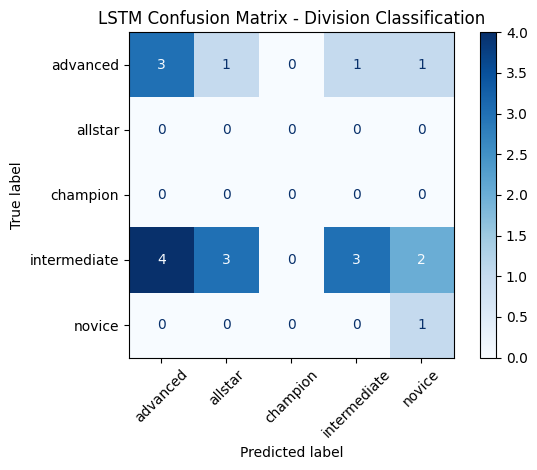

In [61]:
# Plot confusion matrix
classes = sorted(id2label.keys())
cm = confusion_matrix(true_labels, preds, labels=classes)
display_labels = [id2label[c] for c in classes]

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', values_format="d", xticks_rotation=45)

if cm.max() == cm.min():
    disp.im_.set_clim(0, cm.max() + 1)

plt.title("LSTM Confusion Matrix - Division Classification")
plt.tight_layout()
plt.show()

### 1.6 Misclassification Analysis

In [62]:
# Analyze misclassified samples
mis_idx = [i for i in range(len(preds)) if preds[i] != true_labels[i]]
accuracy = (len(preds) - len(mis_idx)) / len(preds)

print(f"Misclassified: {len(mis_idx)} | Accuracy: {accuracy:.3f}")

if mis_idx:
    print("\nMisclassification details (first 5):")
    for i in mis_idx[:5]:
        true_div = id2label[true_labels[i]]
        pred_div = id2label[preds[i]]
        print(f"  Sample {i}: True={true_div:12} | Pred={pred_div:12} | Conf={confidences[i]:.3f}")

Misclassified: 12 | Accuracy: 0.368

Misclassification details (first 5):
  Sample 2: True=intermediate | Pred=allstar      | Conf=0.805
  Sample 3: True=intermediate | Pred=advanced     | Conf=0.582
  Sample 6: True=advanced     | Pred=intermediate | Conf=0.880
  Sample 7: True=intermediate | Pred=novice       | Conf=0.898
  Sample 8: True=intermediate | Pred=allstar      | Conf=0.937


**LSTM Analysis - Temporal Importance Visualization**

In [63]:
# For LSTM models, we analyze temporal importance instead of spatial heatmaps
def analyze_temporal_importance(keypoints_seq, model, sequence_length):
    """Analyze which time steps are most important for the LSTM's decision"""
    model.eval()
    
    # Preprocess the sequence
    x = preprocess_keypoints_sequence(keypoints_seq, sequence_length).to(device_name)
    
    # Get LSTM outputs for each time step
    with torch.no_grad():
        # Get LSTM hidden states for all time steps
        lstm_out, (h_n, c_n) = model.lstm(x)
        
        # Get classification weights
        fc_weights = model.fc.weight.data  # (num_classes, hidden_size)
        
        # Calculate importance scores for each time step
        # Importance = |output · weight| for the predicted class
        pred_class = model(x).argmax(1).item()
        class_weights = fc_weights[pred_class]  # (hidden_size,)
        
        # Calculate importance per time step
        importance_scores = []
        for t in range(lstm_out.shape[1]):  # for each time step
            timestep_output = lstm_out[0, t, :]  # (hidden_size,)
            importance = torch.abs(torch.dot(timestep_output, class_weights)).item()
            importance_scores.append(importance)
        
        # Normalize importance scores
        importance_scores = np.array(importance_scores)
        importance_scores = importance_scores / (importance_scores.max() + 1e-8)
        
    return importance_scores

def plot_temporal_importance(keypoints_seq, importance_scores, title="Temporal Importance"):
    """Plot the importance of each time step"""
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(importance_scores, 'b-', linewidth=2)
    plt.xlabel('Time Step')
    plt.ylabel('Importance Score')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    # Show X,Y trajectory (first keypoint)
    keypoints_xy = keypoints_seq[:, :, :2]  # Use only x,y for trajectory
    if keypoints_xy.shape[1] > 0:
        plt.plot(keypoints_xy[:, 0, 0], keypoints_xy[:, 0, 1], 'r-o', markersize=3)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Keypoint 0 Trajectory (X,Y)')
        plt.axis('equal')
        plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    # Show Z movement (first keypoint)
    keypoints_z = keypoints_seq[:, :, 2]  # Z coordinate only
    if keypoints_z.shape[1] > 0:
        plt.plot(keypoints_z[:, 0], 'g-o', markersize=3)
        plt.xlabel('Time Step')
        plt.ylabel('Z Coordinate')
        plt.title('Keypoint 0 Z Movement')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

**Visualize Temporal Importance for Examples**

=== CORRECT PREDICTION ANALYSIS ===
Example 0: True=intermediate, Pred=intermediate, Conf=0.879


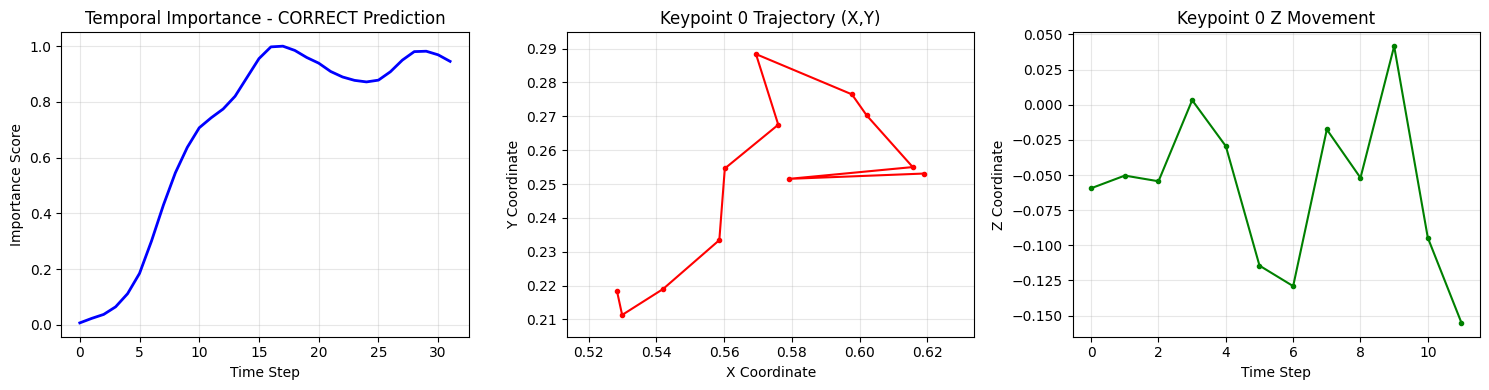


=== INCORRECT PREDICTION ANALYSIS ===
Example 2: True=intermediate, Pred=allstar, Conf=0.805


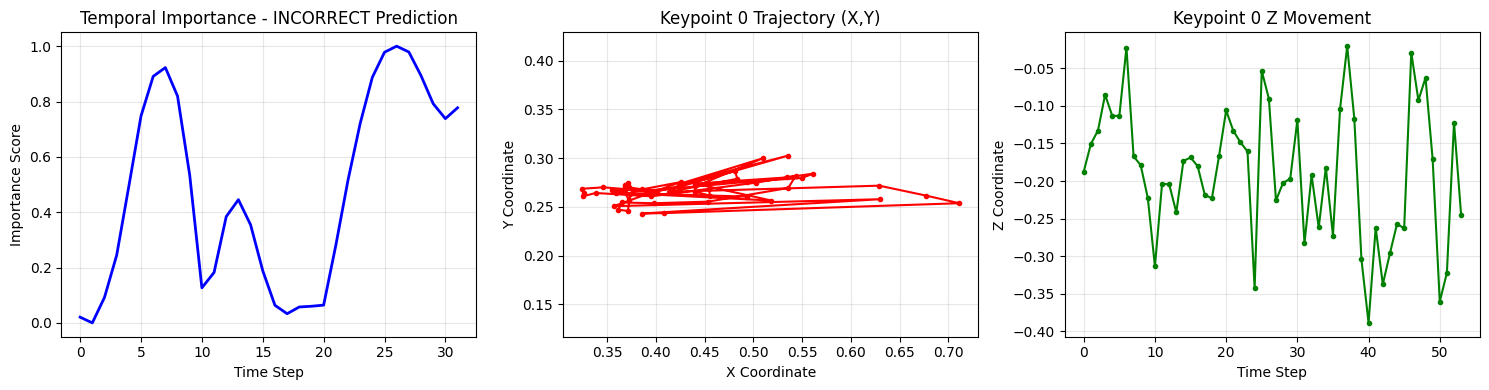

In [64]:
def analyze_example(idx):
    """Analyze temporal importance for a specific example"""
    keypoints_seq = keypoints_sequences[idx]
    true_label = id2label[true_labels[idx]]
    pred_label = id2label[preds[idx]]
    confidence = confidences[idx]
    
    print(f"Example {idx}: True={true_label}, Pred={pred_label}, Conf={confidence:.3f}")
    
    # Analyze temporal importance
    importance_scores = analyze_temporal_importance(keypoints_seq, model, sequence_length)
    
    # Plot results
    is_correct = true_labels[idx] == preds[idx]
    status = "CORRECT" if is_correct else "INCORRECT"
    plot_temporal_importance(keypoints_seq, importance_scores, 
                           f"Temporal Importance - {status} Prediction")

# Analyze a correct prediction
correct_indices = [i for i in range(len(preds)) if preds[i] == true_labels[i]]
if correct_indices:
    print("=== CORRECT PREDICTION ANALYSIS ===")
    analyze_example(correct_indices[0])

# Analyze an incorrect prediction  
incorrect_indices = [i for i in range(len(preds)) if preds[i] != true_labels[i]]
if incorrect_indices:
    print("\n=== INCORRECT PREDICTION ANALYSIS ===")
    analyze_example(incorrect_indices[0])

**Analyze Multiple Examples**

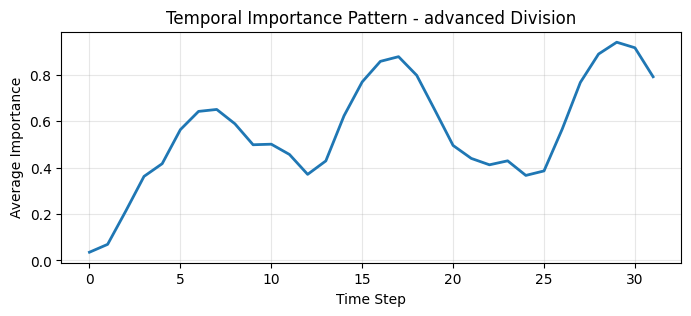

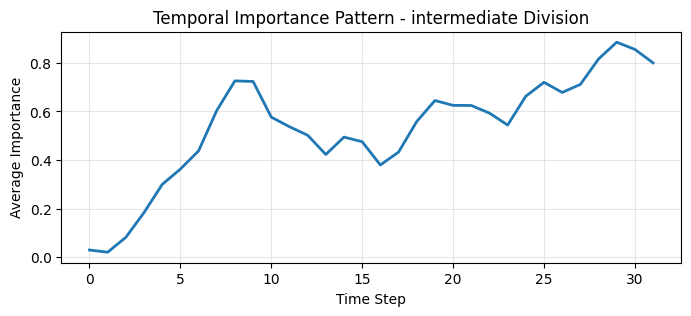

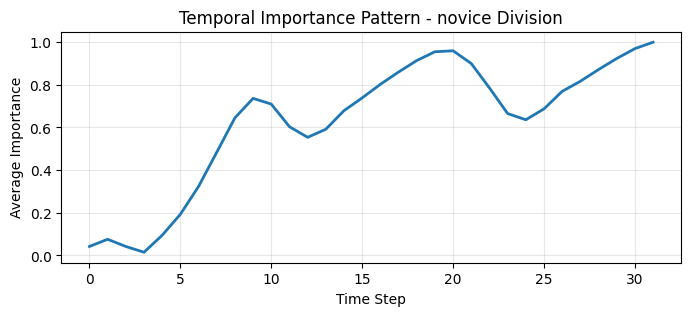

Division-specific temporal analysis complete!


In [65]:
# Analyze temporal patterns for different divisions
division_analysis = {}

for division in id2label.values():
    division_indices = [i for i in range(len(true_labels)) if id2label[true_labels[i]] == division]
    if division_indices:
        # Collect importance scores for this division
        all_importance = []
        for idx in division_indices[:3]:  # Analyze first 3 examples per division
            importance = analyze_temporal_importance(keypoints_sequences[idx], model, sequence_length)
            all_importance.append(importance)
        
        # Average importance pattern for this division
        avg_importance = np.mean(all_importance, axis=0)
        division_analysis[division] = avg_importance
        
        plt.figure(figsize=(8, 3))
        plt.plot(avg_importance, linewidth=2, label=f'{division} (n={len(division_indices)})')
        plt.xlabel('Time Step')
        plt.ylabel('Average Importance')
        plt.title(f'Temporal Importance Pattern - {division} Division')
        plt.grid(True, alpha=0.3)
        plt.show()

print("Division-specific temporal analysis complete!")

**Division-Level Performance Analysis**

=== Division-Level Performance ===
advanced: 0.500 accuracy (6 samples)
intermediate: 0.250 accuracy (12 samples)
novice: 1.000 accuracy (1 samples)


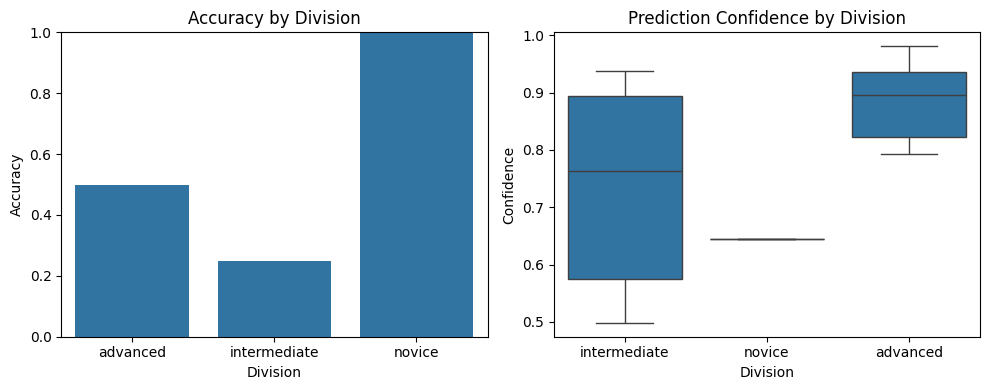


=== Overall Performance ===
Overall Accuracy: 0.368
Average Confidence: 0.781


In [66]:
# Create a DataFrame for sequence-level results
results_df = pd.DataFrame({
    "true_label": true_labels,
    "pred": preds,
    "confidence": confidences,
    "sequence_idx": range(len(preds))
})

# Add division names
results_df["true_division"] = results_df["true_label"].apply(lambda x: id2label[x])
results_df["pred_division"] = results_df["pred"].apply(lambda x: id2label[x])
results_df["correct"] = results_df["true_label"] == results_df["pred"]

# Calculate accuracy per division
division_acc = results_df.groupby("true_division")["correct"].mean()
division_counts = results_df.groupby("true_division").size()

print("=== Division-Level Performance ===")
for division in division_acc.index:
    acc = division_acc[division]
    count = division_counts[division]
    print(f"{division}: {acc:.3f} accuracy ({count} samples)")

plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
sns.barplot(x=division_acc.index, y=division_acc.values)
plt.title("Accuracy by Division")
plt.ylabel("Accuracy")
plt.xlabel("Division")
plt.ylim(0, 1)

# Confidence plot
plt.subplot(1, 2, 2)
sns.boxplot(data=results_df, x="true_division", y="confidence")
plt.title("Prediction Confidence by Division")
plt.ylabel("Confidence")
plt.xlabel("Division")

plt.tight_layout()
plt.show()

print("\n=== Overall Performance ===")
overall_acc = results_df["correct"].mean()
avg_confidence = results_df["confidence"].mean()
print(f"Overall Accuracy: {overall_acc:.3f}")
print(f"Average Confidence: {avg_confidence:.3f}")

---
## Decision Tree Analysis (Nguyen Pham)

### 2.1 Load Model and Data

In [ ]:
# =====================================================
# Decision Tree Analysis - Load Model and Data
# =====================================================

import joblib
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
import math

# Paths
DT_MODEL_PATH = Path("../data/processed/decision_tree_classifier.joblib")
DT_DATA_DIR = Path('../data/keypoints_1')
DT_LABELS_CSV = Path('../data/hp.csv')

# Load the saved Decision Tree model
dt_model = joblib.load(DT_MODEL_PATH)
print(f"Loaded Decision Tree model from {DT_MODEL_PATH}")

# =====================================================
# Helper functions for loading and preprocessing
# =====================================================

def dt_find_videos(root=DT_DATA_DIR, labels_csv=DT_LABELS_CSV):
    records = []
    
    if not labels_csv.exists():
        raise FileNotFoundError(f"Labels CSV not found: {labels_csv}")
    if not root.exists():
        raise FileNotFoundError(f"Data dir not found: {root}")
    
    df = pd.read_csv(labels_csv)
    
    missing_videos = []
    
    for _, row in df.iterrows():
        division = row['division']
        video_id = row['id']
        video_name = f"{division}_{video_id}"
        trick_label = row['labels']
        
        # Build expected path
        np_path = root / division / video_name / 'keypoints.npy'
        
        if np_path.exists():
            records.append({
                'label': trick_label,
                'division': division,
                'video': video_name,
                'np_path': np_path,
            })
        else:
            missing_videos.append(video_name)
    
    if missing_videos:
        print(f"Warning: {len(missing_videos)} videos from hp.csv not found in keypoints folder:")
        for v in missing_videos[:5]:
            print(f"  - {v}")
        if len(missing_videos) > 5:
            print(f"  ... and {len(missing_videos) - 5} more")
    
    print(f"Loaded {len(records)} videos (matching hp.csv)")
    return pd.DataFrame(records)

def dt_load_keypoints(np_path):
    arr = np.load(np_path)
    return arr.astype(np.float32)

def interpolate_missing(arr, visibility_threshold=0.1):
    out = arr.copy()
    for lm in range(out.shape[1]):
        vis = out[:, lm, 3]
        bad = vis < visibility_threshold
        if bad.all():
            continue
        for d in range(3):
            vals = out[:, lm, d].astype(float)
            vals[bad] = np.nan
            s = pd.Series(vals)
            vals_filled = s.interpolate(limit_direction='both').bfill().ffill().values
            out[:, lm, d] = vals_filled.astype(np.float32)
    return out

def torso_scale_single(lm):
    left_sh = lm[11][:2]
    right_sh = lm[12][:2]
    left_hip = lm[23][:2]
    right_hip = lm[24][:2]
    mid_sh = (left_sh + right_sh) / 2.0
    mid_hip = (left_hip + right_hip) / 2.0
    d = np.linalg.norm(mid_sh - mid_hip)
    return max(d, 1e-6)

def normalize_by_torso(arr):
    out = arr.copy()
    for t in range(out.shape[0]):
        lm = out[t]
        hip_center = (lm[23][:2] + lm[24][:2]) / 2.0
        scale = torso_scale_single(lm)
        out[t, :, :2] = (lm[:, :2] - hip_center) / scale
    return out

def pad_or_truncate(arr, target_len=64, strategy='center'):
    T = arr.shape[0]
    if T == target_len:
        return arr
    if T > target_len:
        if strategy == 'center':
            start = max(0, (T - target_len) // 2)
            return arr[start:start+target_len]
        return arr[:target_len]
    pad = np.zeros((target_len - T, arr.shape[1], arr.shape[2]), dtype=arr.dtype)
    return np.concatenate([arr, pad], axis=0)

def angle_at(a, b, c):
    ba = a - b
    bc = c - b
    lena = np.linalg.norm(ba)
    lenb = np.linalg.norm(bc)
    if lena < 1e-6 or lenb < 1e-6:
        return 0.0
    cosang = np.dot(ba, bc) / (lena * lenb)
    cosang = np.clip(cosang, -1.0, 1.0)
    return math.acos(cosang)

ANGLE_TRIPLETS = [(11, 13, 15), (12, 14, 16), (23, 25, 27), (24, 26, 28)]

def compute_frame_features(seq):
    T = seq.shape[0]
    flat = seq[:, :, :3].reshape(T, -1)
    
    angles = np.zeros((T, len(ANGLE_TRIPLETS)), dtype=np.float32)
    for t in range(T):
        for i, (a, b, c) in enumerate(ANGLE_TRIPLETS):
            angles[t, i] = angle_at(seq[t, a, :2], seq[t, b, :2], seq[t, c, :2])
    
    important = [11, 12, 23, 24, 13, 14, 25, 26]
    pdists = []
    for t in range(T):
        coords = seq[t, important, :2]
        dists = []
        for i in range(coords.shape[0]):
            for j in range(i+1, coords.shape[0]):
                dists.append(np.linalg.norm(coords[i] - coords[j]))
        pdists.append(dists)
    pdists = np.array(pdists)
    
    vel = np.vstack((np.zeros((1, flat.shape[1])), np.diff(flat, axis=0)))
    feats = np.concatenate([flat, angles, pdists, vel], axis=1)
    return feats

def aggregate_video_features(seq, target_len=64):
    seq = interpolate_missing(seq)
    seq = normalize_by_torso(seq)
    seq = pad_or_truncate(seq, target_len=target_len)
    
    frame_feats = compute_frame_features(seq)
    mean = frame_feats.mean(axis=0)
    std = frame_feats.std(axis=0)
    
    return np.concatenate([mean, std])

# =====================================================
# Load data and build feature matrix
# =====================================================

dt_df = dt_find_videos()

# Build feature matrix
dt_X = []
dt_y = []
dt_meta_records = []

for _, r in dt_df.iterrows():
    seq = dt_load_keypoints(r['np_path'])
    vec = aggregate_video_features(seq, target_len=64)
    dt_X.append(vec)
    dt_y.append(r['label'])
    dt_meta_records.append({
        'label': r['label'],
        'division': r.get('division', ''),
        'video': r['video'],
    })

dt_X = np.array(dt_X)
dt_y = np.array(dt_y)
dt_meta = pd.DataFrame(dt_meta_records)

# Filter for target classes (sugar_push and sugar_tag)
target_classes = ['sugar_push', 'sugar_tag']
mask = np.isin(dt_y, target_classes)
dt_X = dt_X[mask]
dt_y = dt_y[mask]
dt_meta = dt_meta[mask].reset_index(drop=True)

Loaded Decision Tree model from ../data/processed/decision_tree_classifier.joblib
  - advanced_11
Loaded 19 videos (matching hp.csv)
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230


**Decision Tree - Dimensionality Reduction and Visualization**

In [68]:
def do_dimensionality_reduction(X, n_pca=10):
    n_samples, n_features = X.shape
    print(f'Running PCA -> t-SNE (n_samples={n_samples}, n_features={n_features})...')

    pca_components = max(2, min(n_pca, n_samples, n_features))
    pca = PCA(n_components=pca_components, random_state=0)
    X_pca = pca.fit_transform(X)

    if n_samples < 3:
        print('Too few samples for t-SNE (need >=3). Returning PCA only.')
        return {'pca': X_pca}

    perplexity = min(30, max(2, (n_samples - 1) // 3))
    perplexity = min(perplexity, n_samples - 1)
    
    try:
        tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto', init='pca', random_state=0)
        X_tsne = tsne.fit_transform(X_pca[:, :pca_components])
    except Exception as exc:
        print('t-SNE failed:', exc)
        X_tsne = None
    
    return {'pca': X_pca, 'tsne': X_tsne}

# Run dimensionality reduction for visualization
dt_emb = do_dimensionality_reduction(dt_X)

if 'tsne' in dt_emb and dt_emb['tsne'] is not None:
    dt_emb_plot = dt_emb['tsne']
    dt_method = 't-SNE'
else:
    dt_emb_plot = dt_emb['pca'][:, :2]
    dt_method = 'PCA'

print(f'Using {dt_method} for visualization')

Running PCA -> t-SNE (n_samples=19, n_features=460)...
Using t-SNE for visualization
Using t-SNE for visualization


**Decision Tree - 2D Feature Space Plot**

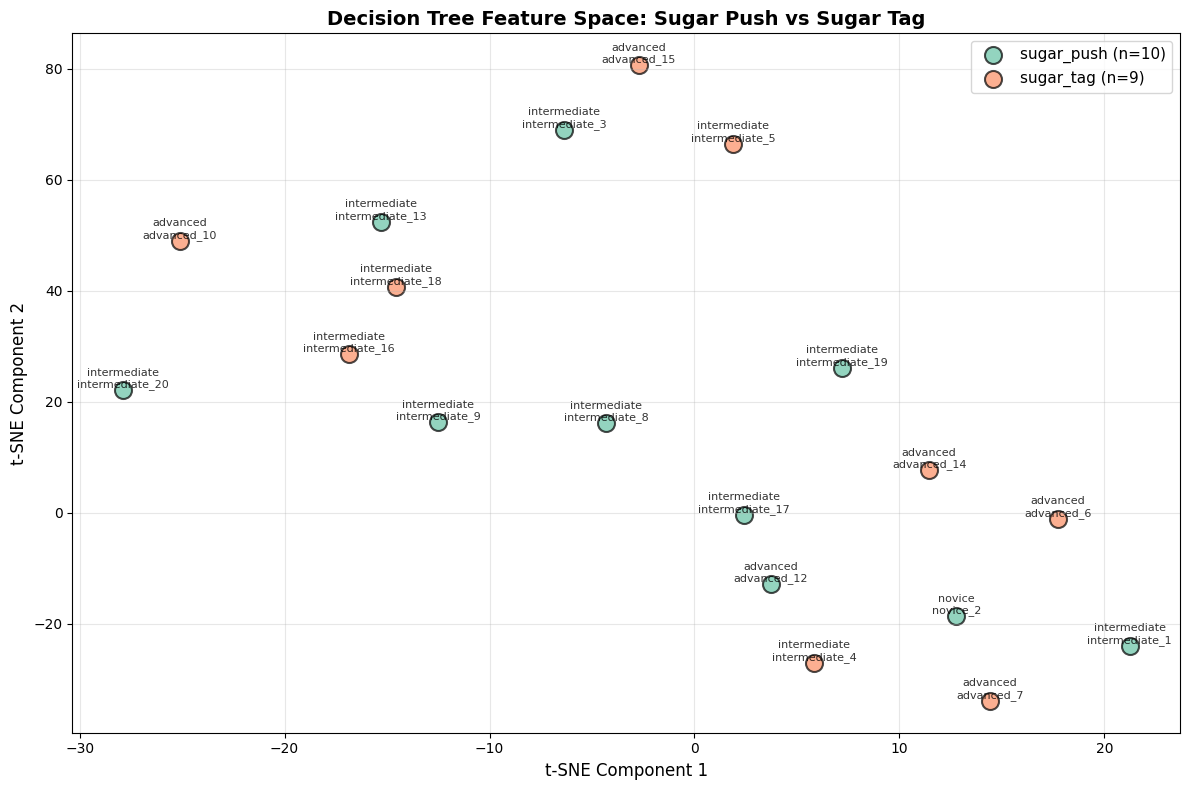

In [69]:
plt.figure(figsize=(12, 8))
unique_labels = np.unique(dt_y)
colors = sns.color_palette('Set2', n_colors=len(unique_labels))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = dt_y == label
    indices = np.where(mask)[0]
    
    plt.scatter(
        dt_emb_plot[mask, 0],
        dt_emb_plot[mask, 1],
        label=f'{label} (n={mask.sum()})',
        s=150,
        alpha=0.7,
        color=label_to_color[label],
        edgecolors='black',
        linewidth=1.5
    )
    
    for idx in indices:
        division = dt_meta.iloc[idx]['division']
        video = dt_meta.iloc[idx]['video']
        plt.annotate(
            f"{division}\n{video}",
            (dt_emb_plot[idx, 0], dt_emb_plot[idx, 1]),
            fontsize=8,
            alpha=0.8,
            ha='center',
            va='bottom'
        )

plt.xlabel(f'{dt_method} Component 1', fontsize=12)
plt.ylabel(f'{dt_method} Component 2', fontsize=12)
plt.title('Decision Tree Feature Space: Sugar Push vs Sugar Tag', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Decision Tree - Predict**

In [70]:
# Load the full dataset using keypoints_2
df_test = dt_find_videos()  

# Make predictions on all data
all_predictions = []
all_true_labels = []
prediction_probs = []

for _, row in df_test.iterrows():
    # Load and preprocess the video
    seq = dt_load_keypoints(row['np_path'])
    vec = aggregate_video_features(seq, target_len=64)
    
    # Predict
    pred = dt_model.predict([vec])[0]
    prob = dt_model.predict_proba([vec])[0]
    
    all_predictions.append(pred)
    all_true_labels.append(row['label'])
    prediction_probs.append(prob)

# Calculate overall accuracy
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
overall_accuracy = accuracy_score(all_true_labels, all_predictions)

# Print results
print(f"Total samples tested: {len(all_predictions)}")
print(f"Overall Accuracy: {overall_accuracy:.2%}")

  - advanced_11
Loaded 19 videos (matching hp.csv)
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
230
Total samples tested: 19
Overall Accuracy: 100.00%
230
230
230
230
230
230
230
Total samples tested: 19
Overall Accuracy: 100.00%


### 2.5 Feature Importance Analysis

Decision Trees provide interpretable feature importance scores showing which engineered features contribute most to pattern classification.

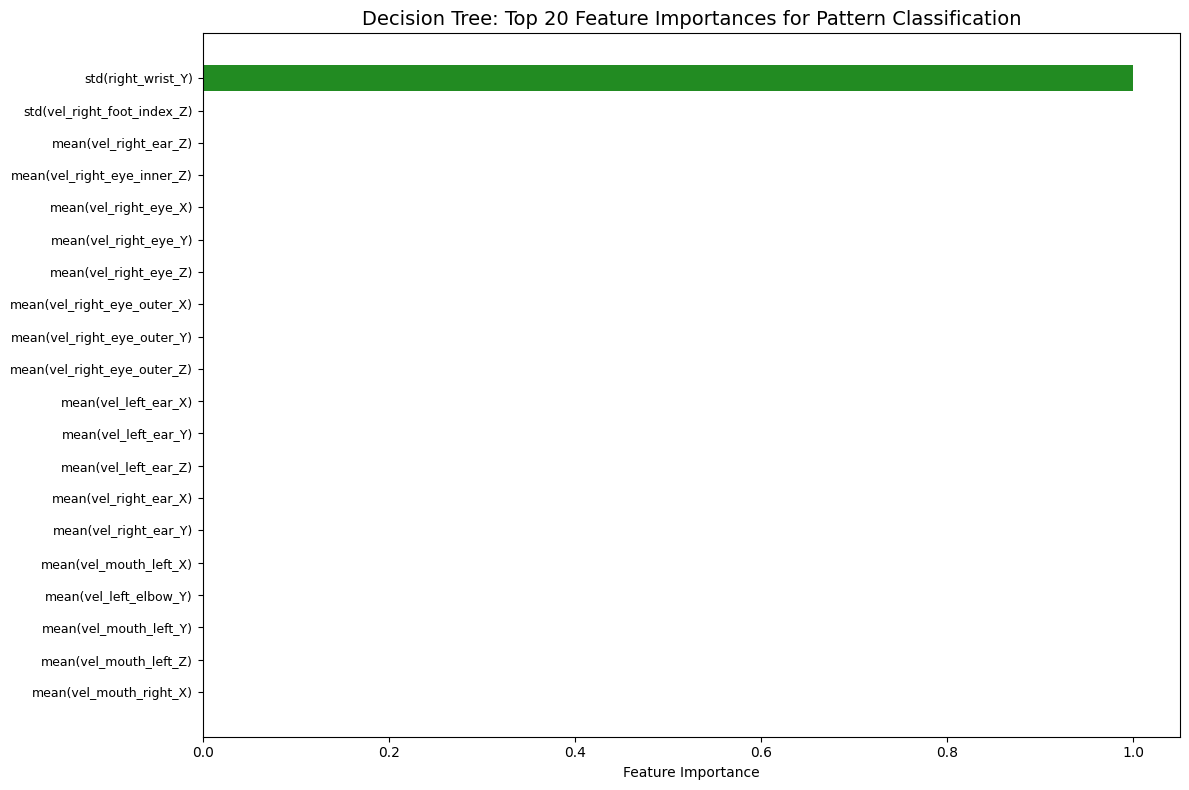


Top 5 Most Important Features:
  1. std(right_wrist_Y): 1.0000
  2. std(vel_right_foot_index_Z): 0.0000
  3. mean(vel_right_ear_Z): 0.0000
  4. mean(vel_right_eye_inner_Z): 0.0000
  5. mean(vel_right_eye_X): 0.0000


In [ ]:
# MediaPipe landmark names (33 landmarks)
LANDMARK_NAMES = [
    'nose', 'left_eye_inner', 'left_eye', 'left_eye_outer', 'right_eye_inner',
    'right_eye', 'right_eye_outer', 'left_ear', 'right_ear', 'mouth_left',
    'mouth_right', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_pinky', 'right_pinky', 'left_index',
    'right_index', 'left_thumb', 'right_thumb', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle', 'left_heel',
    'right_heel', 'left_foot_index', 'right_foot_index'
]

def get_feature_name(idx):
    """Convert feature index to meaningful name"""
    n_landmarks = 33
    n_coords = 3  # X, Y, Z
    n_flat = n_landmarks * n_coords  # 99 flattened keypoint features
    n_angles = 4  # 4 angle triplets
    n_pdists = 28  # C(8,2) = 28 pairwise distances between 8 important joints
    n_vel = n_flat  # 99 velocity features
    
    # Per-frame features: flat (99) + angles (4) + pdists (28) + vel (99) = 230
    n_frame_features = n_flat + n_angles + n_pdists + n_vel  # 230
    
    # Aggregated: mean (230) + std (230) = 460 total features
    is_std = idx >= n_frame_features
    local_idx = idx % n_frame_features
    stat_type = "std" if is_std else "mean"
    
    if local_idx < n_flat:
        # Flattened keypoints (X, Y, Z for each landmark)
        landmark_idx = local_idx // n_coords
        coord_idx = local_idx % n_coords
        coord_name = ['X', 'Y', 'Z'][coord_idx]
        landmark_name = LANDMARK_NAMES[landmark_idx] if landmark_idx < len(LANDMARK_NAMES) else f"lm{landmark_idx}"
        return f"{stat_type}({landmark_name}_{coord_name})"
    
    local_idx -= n_flat
    if local_idx < n_angles:
        # Joint angles
        angle_names = ['left_elbow_angle', 'right_elbow_angle', 'left_knee_angle', 'right_knee_angle']
        return f"{stat_type}({angle_names[local_idx]})"
    
    local_idx -= n_angles
    if local_idx < n_pdists:
        # Pairwise distances between important joints
        important = ['left_shoulder', 'right_shoulder', 'left_hip', 'right_hip', 
                     'left_elbow', 'right_elbow', 'left_knee', 'right_knee']
        pairs = []
        for i in range(len(important)):
            for j in range(i+1, len(important)):
                pairs.append(f"{important[i]}-{important[j]}")
        return f"{stat_type}(dist_{pairs[local_idx]})"
    
    local_idx -= n_pdists
    if local_idx < n_vel:
        # Velocity features
        landmark_idx = local_idx // n_coords
        coord_idx = local_idx % n_coords
        coord_name = ['X', 'Y', 'Z'][coord_idx]
        landmark_name = LANDMARK_NAMES[landmark_idx] if landmark_idx < len(LANDMARK_NAMES) else f"lm{landmark_idx}"
        return f"{stat_type}(vel_{landmark_name}_{coord_name})"
    
    return f"feature_{idx}"

# Plot feature importance with meaningful names
if hasattr(dt_model, 'feature_importances_'):
    dt_importances = dt_model.feature_importances_
    
    # Get top 20 most important features
    n_top = min(20, len(dt_importances))
    top_indices = np.argsort(dt_importances)[-n_top:][::-1]
    top_importances = dt_importances[top_indices]
    
    # Get meaningful feature names
    feature_names = [get_feature_name(i) for i in top_indices]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(n_top), top_importances[::-1], color='forestgreen')
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(feature_names[::-1], fontsize=9)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Decision Tree: Top 20 Feature Importances for Pattern Classification', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print top features with explanations
    print("\nTop 5 Most Important Features:")
    for i, (idx, imp) in enumerate(zip(top_indices[:5], top_importances[:5])):
        print(f"  {i+1}. {feature_names[i]}: {imp:.4f}")
else:
    print("Could not extract feature importances from the model")